In [17]:
import os
os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.visualization import ZScaleInterval
from astropy.io import fits
import scripts.phot_toolkits as phot_tk
from scipy.spatial import KDTree

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
JWST_files              = phot_tk.Pipeline_level_2_data(working_directory = "../../../../../../../../net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_2/",)


In [3]:
cal_file_names          = JWST_files.find_calibrated_filenames(filter='F187N')
JWST_files.find_calibration_versions(cal_file_names[1])

JWST pipeline version             : 2.0.1
Calibration Reference Data System : 13.1.13
CRDS context map                  : jwst_1535.pmap
Read-out pattern                  : BRIGHT2
Number of read-out groups         : 2


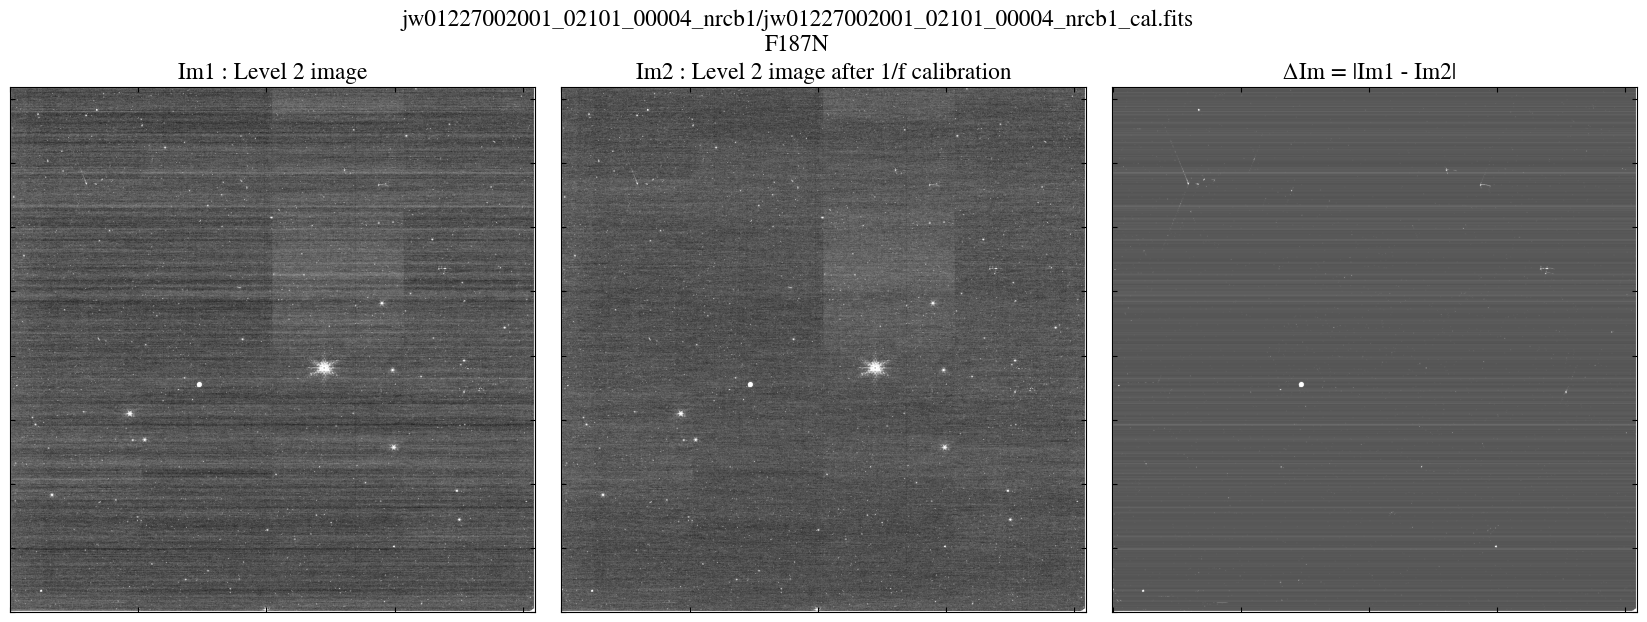

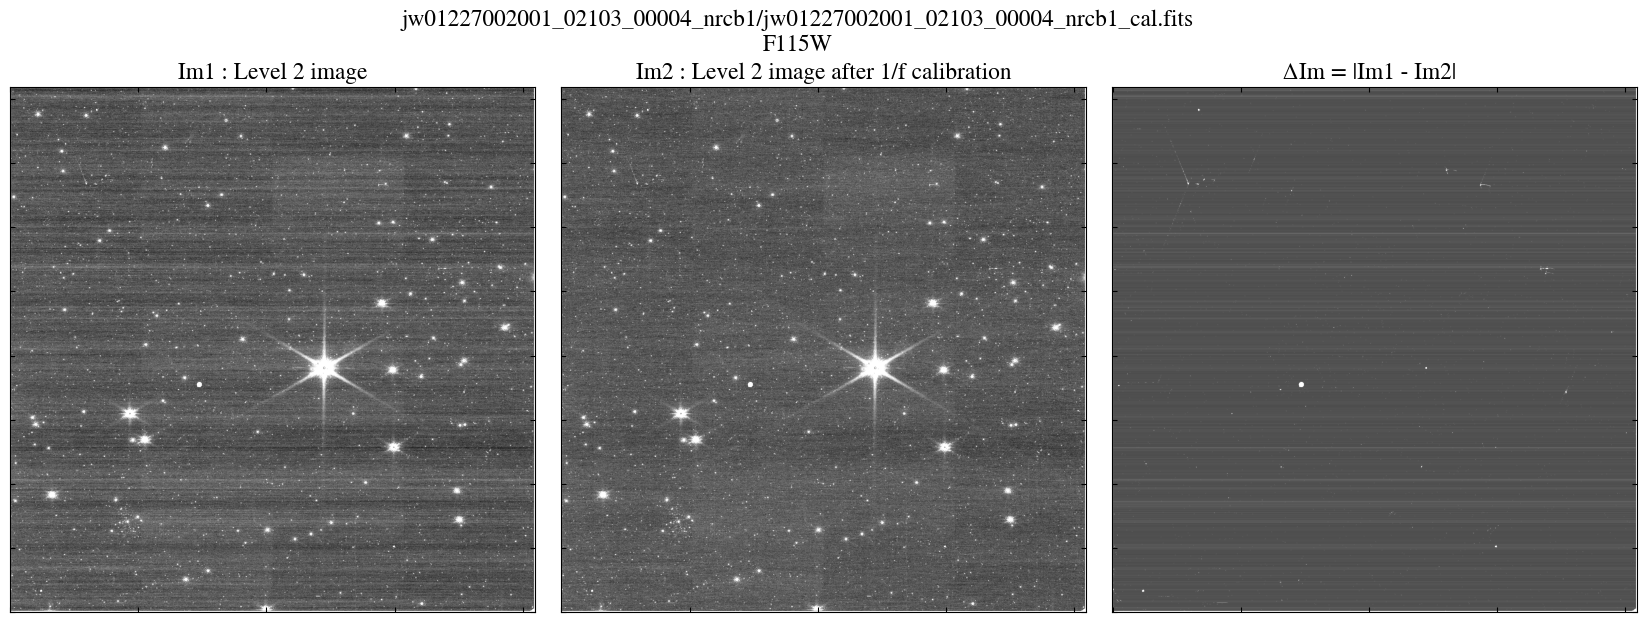

In [5]:
IMAGE_INDEX = 28

JWST_files.show_level2_and_one_over_f_difference(IMAGE_INDEX=IMAGE_INDEX, filter = 'F187N')
JWST_files.show_level2_and_one_over_f_difference(IMAGE_INDEX=IMAGE_INDEX, filter = 'F115W')

In [ ]:
JWST_files.starbug2_aperture_photometry(IMAGE_INDEX             = IMAGE_INDEX
                                        ,filter                 = 'F187N'
                                        ,remove_background      = True
                                        ,overwrite_always_run   = False)

JWST_files.starbug2_aperture_photometry(IMAGE_INDEX             = IMAGE_INDEX
                                        ,filter                 = 'F115W'
                                        ,remove_background      = True
                                        ,overwrite_always_run   = False)


In [ ]:
JWST_files.show_one_over_f_SB2(  IMAGE_INDEX            = IMAGE_INDEX
                                ,filter                 = 'F187N'
                                ,safefig                = True
                                ,detection_sigma        = 2.0)

JWST_files.show_one_over_f_SB2(  IMAGE_INDEX            = IMAGE_INDEX
                                ,filter                 = 'F115W'
                                ,safefig                = True
                                ,detection_sigma        = 2.0)

In [ ]:
JWST_files.assign_WCS_from_gaia_dr3(IMAGE_INDEX=IMAGE_INDEX, filter='F115W')

Found 247 matching detections


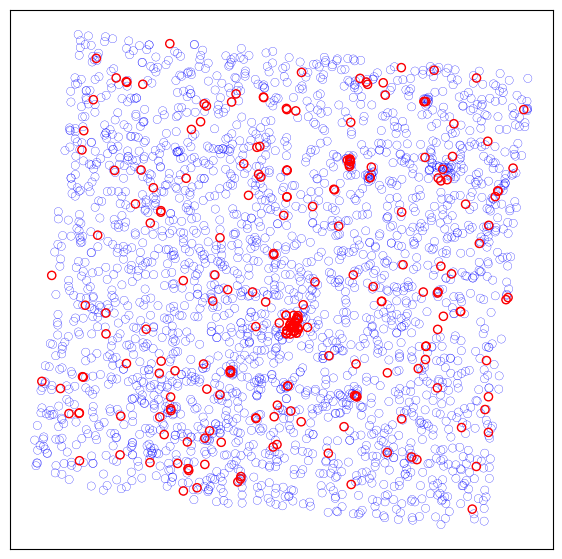

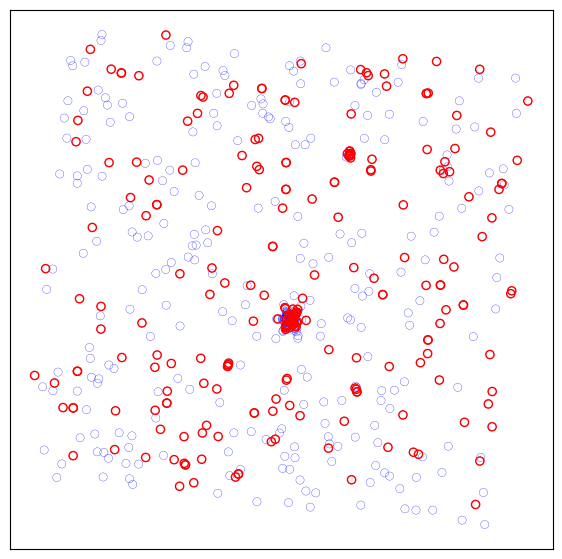

In [47]:
JWST_files.show_detections(IMAGE_INDEX=IMAGE_INDEX, det_tol = 1e-4, save=True)

In [35]:

A = np.array(([2,2], [1,1], [3,5]))
B = np.array(([2,2.1], [1,1], [3,5], [3,4]))
print(A.shape)
print(B.shape)
tol = 0.11

tree    = KDTree(B)
matches = tree.query_ball_point(A, r=tol)

a_idx = []
b_idx = []
for i, match in enumerate(matches):
    for j in match:
        a_idx.append(i)
        b_idx.append(j)

a_idx = np.array(a_idx)
b_idx = np.array(b_idx)

print(A[a_idx, 0])


(3, 2)
(4, 2)
[2 1 3]


In [ ]:
JWST_files.show_alignment(IMAGE_INDEX=0, filter='F187N')

In [ ]:
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(science_field)


plt.figure(figsize=(10, 10))
plt.imshow(science_field, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)

# 4. Overplot the source detections as open circles
plt.scatter(x_positions_sources, y_positions_sources, s=40, facecolors='none', edgecolors='red', linewidths=1.2, label='Starbug2 Detections')

plt.legend()
plt.title('Starbug2 Source Detections Overplot')
plt.show()